In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score
)
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import linkage, dendrogram

output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

data = pd.read_csv(
    output_dir / "sparrow_model_data.csv",
    dtype={"ID": "string"}
)

cluster_data = data.loc[
    data["Split"] == "train"
].copy()

features = [
    "BuildingHeight",
    "BuildingWidth",
    "Altitude",
    "AveNoise",
    "temp",
    "prec",
    "win"
]

X = cluster_data[features].copy()

print("Clustering records:", len(X))

Clustering records: 501


In [2]:
# standardize the features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

scaled_table = pd.DataFrame(
    X_scaled,
    columns=features,
    index=X.index
)

display(scaled_table.head())

,BuildingHeight,BuildingWidth,Altitude,AveNoise,temp,prec,win
0,-0.074986,0.202433,-1.789198,-2.428403,1.571267,1.706067,0.03402
1,-0.206866,0.678749,-1.789198,-2.057076,1.571267,1.706067,0.03402
2,-0.074986,0.202433,-1.789198,-0.943093,1.571267,1.706067,0.03402
3,-0.074986,0.202433,-1.789198,-0.571766,1.571267,1.706067,0.03402
4,-0.074986,0.202433,-1.789198,-2.180851,1.571267,1.706067,0.03402


In [3]:
# check the number of cluster
results = []
fitted_models = {}
cluster_labels = {}

for k in range(2, 7):
    candidates = {
        "K-means": KMeans(
            n_clusters=k,
            n_init=20,
            random_state=42
        ),

        "Hierarchical-average": AgglomerativeClustering(
            n_clusters=k,
            linkage="average"
        )
    }

    for name, model in candidates.items():
        labels = model.fit_predict(X_scaled)

        counts = pd.Series(labels).value_counts()

        results.append({
            "Method": name,
            "k": k,
            "Silhouette": silhouette_score(
                X_scaled, labels
            ),
            "CalinskiHarabasz": calinski_harabasz_score(
                X_scaled, labels
            ),
            "SmallestCluster": counts.min(),
            "LargestCluster": counts.max(),
            "Inertia": (
                model.inertia_
                if name == "K-means"
                else float("nan")
            )
        })

        fitted_models[(name, k)] = model
        cluster_labels[(name, k)] = labels

clustering_results = pd.DataFrame(results)

display(clustering_results.round(4))

,Method,k,Silhouette,CalinskiHarabasz,SmallestCluster,LargestCluster,Inertia
0,K-means,2,0.2475,180.9787,236,265,2573.5999
1,Hierarchical-average,2,0.4381,9.7114,2,499,NaN
2,K-means,3,0.2635,157.3610,102,205,2148.9340
3,Hierarchical-average,3,0.3342,7.8490,2,497,NaN
4,K-means,4,0.2560,145.7075,76,164,1865.8998
5,Hierarchical-average,4,0.2889,53.5390,2,422,NaN
6,K-means,5,0.2675,140.6032,51,156,1643.4722
7,Hierarchical-average,5,0.2551,40.6101,1,422,NaN
8,K-means,6,0.2556,129.9312,57,119,1516.5824
9,Hierarchical-average,6,0.1753,35.0599,1,416,NaN


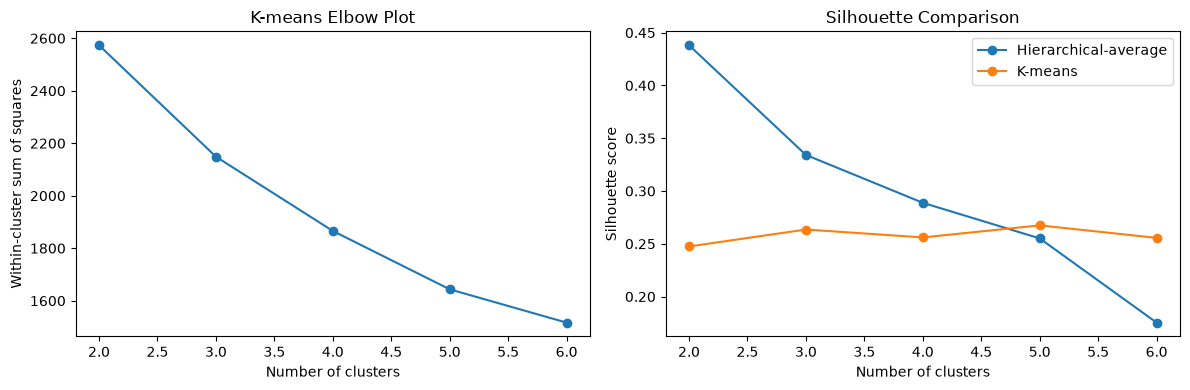

In [4]:
# evaluation chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

km_results = clustering_results.loc[
    clustering_results["Method"] == "K-means"
]

axes[0].plot(
    km_results["k"],
    km_results["Inertia"],
    marker="o"
)

axes[0].set_title("K-means Elbow Plot")
axes[0].set_xlabel("Number of clusters")
axes[0].set_ylabel("Within-cluster sum of squares")

for name, group in clustering_results.groupby("Method"):
    axes[1].plot(
        group["k"],
        group["Silhouette"],
        marker="o",
        label=name
    )

axes[1].set_title("Silhouette Comparison")
axes[1].set_xlabel("Number of clusters")
axes[1].set_ylabel("Silhouette score")
axes[1].legend()

plt.tight_layout()

plt.savefig(
    output_dir / "clustering_evaluation.png",
    dpi=200
)

plt.show()

In [5]:
# choose provisional k-means soluation
selected_row = km_results.loc[
    km_results["Silhouette"].idxmax()
]

selected_k = int(selected_row["k"])

selected_labels = cluster_labels[
    ("K-means", selected_k)
]

selected_model = fitted_models[
    ("K-means", selected_k)
]

cluster_data["Cluster"] = selected_labels

print("Provisional K:", selected_k)

display(
    cluster_data["Cluster"]
    .value_counts()
    .sort_index()
)

Provisional K: 5


Cluster
0    125
1     76
2    156
3     93
4     51
Name: count, dtype: int64

In [6]:
# Read the cluster profile
cluster_profiles = (
    cluster_data
    .groupby("Cluster")[features]
    .mean()
)

cluster_profiles.insert(
    0,
    "Records",
    cluster_data.groupby("Cluster").size()
)

display(cluster_profiles.round(2))

,Records,BuildingHeight,BuildingWidth,Altitude,AveNoise,temp,prec,win
Cluster,,,,,,,,
0,125,22.97,48.82,789.88,54.72,16.80,58.55,2.57
1,76,44.48,41.88,53.92,52.59,20.03,68.17,2.43
2,156,21.23,59.28,1269.50,49.27,15.75,28.98,2.65
3,93,24.51,48.62,1480.95,50.00,15.50,53.55,1.92
4,51,79.25,52.14,881.14,52.71,16.72,56.19,2.44


In [7]:
# connect with nest-count
nest_profiles = (
    cluster_data.groupby("Cluster")
    .agg(
        Records=("NestCount", "size"),
        MeanNestCount=("NestCount", "mean"),
        MedianNestCount=("NestCount", "median"),
        HigherCountFraction=("HigherNestCount", "mean")
    )
)

display(nest_profiles.round(3))

,Records,MeanNestCount,MedianNestCount,HigherCountFraction
Cluster,,,,
0,125,5.312,5.0,0.576
1,76,13.579,12.0,0.895
2,156,3.782,3.0,0.276
3,93,2.860,2.0,0.172
4,51,5.647,5.0,0.510


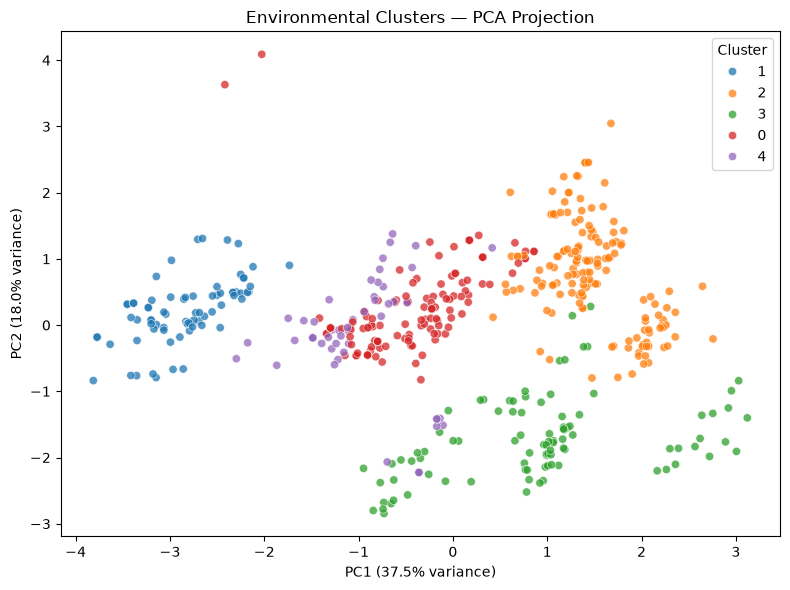

Variance represented by the plot: 55.53 %


In [8]:
# 2D diagram using PCA
pca = PCA(n_components=2)

coordinates = pca.fit_transform(X_scaled)

plot_data = pd.DataFrame({
    "PC1": coordinates[:, 0],
    "PC2": coordinates[:, 1],
    "Cluster": selected_labels.astype(str)
})

explained = pca.explained_variance_ratio_

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=plot_data,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    alpha=0.75
)

plt.xlabel(f"PC1 ({explained[0]:.1%} variance)")
plt.ylabel(f"PC2 ({explained[1]:.1%} variance)")
plt.title("Environmental Clusters — PCA Projection")
plt.tight_layout()

plt.savefig(
    output_dir / "cluster_pca.png",
    dpi=200
)

plt.show()

print(
    "Variance represented by the plot:",
    round(explained.sum() * 100, 2),
    "%"
)

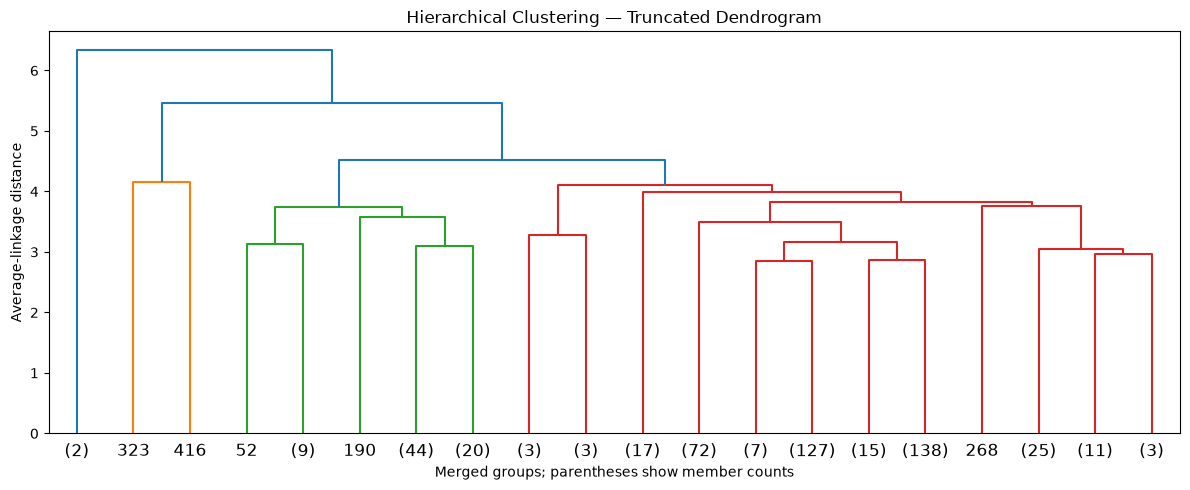

In [9]:
# hierarchical dendrogram
linkage_matrix = linkage(
    X_scaled,
    method="average",
    metric="euclidean"
)

plt.figure(figsize=(12, 5))

dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=20,
    show_leaf_counts=True
)

plt.title("Hierarchical Clustering — Truncated Dendrogram")
plt.xlabel("Merged groups; parentheses show member counts")
plt.ylabel("Average-linkage distance")
plt.tight_layout()

plt.savefig(
    output_dir / "hierarchical_dendrogram.png",
    dpi=200
)

plt.show()

In [10]:
# save output
clustering_results.to_csv(
    output_dir / "clustering_results.csv",
    index=False
)

cluster_profiles.to_csv(
    output_dir / "cluster_profiles.csv",
    index_label="Cluster"
)

nest_profiles.to_csv(
    output_dir / "cluster_nest_profiles.csv",
    index_label="Cluster"
)

cluster_data.to_csv(
    output_dir / "sparrow_cluster_assignments.csv",
    index=False
)

print("Clustering outputs saved.")

Clustering outputs saved.
